# ResNet50 Pipeline for Existing Combined Dataset

This notebook trains pretrained ResNet50 using an existing combined dataset folder with:

```text
combined_dataset/
├── train/
├── val/
└── test/
```

It skips generation and merging. It includes checkpoints, best model saving, metrics, curves, and ROC-AUC.


## Install Dependencies

In [1]:
import sys
!{sys.executable} -m pip install -q torch torchvision torchaudio scikit-learn pandas matplotlib tqdm pillow


## Imports

In [2]:
import os, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


## Configuration

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Change this to your existing combined dataset folder.
combined_dataset_dir = r"Philippine Medicinal Plant Leaf Dataset/COMBINED_REAL_cWGAN_VGG19"

train_dir = os.path.join(combined_dataset_dir, "train")
val_dir = os.path.join(combined_dataset_dir, "val")
test_dir = os.path.join(combined_dataset_dir, "test")

batch_size = 16
epochs = 60
lr = 0.0001
l2_regularizer = 0.0001
dropout_rate = 0.50
frozen_layers = 75

results_dir = "resnet50_existing_combined_results"
os.makedirs(results_dir, exist_ok=True)

best_model_path = os.path.join(results_dir, "best_resnet50.pth")
checkpoint_path = os.path.join(results_dir, "latest_resnet50_checkpoint.pth")

resume_training = False


Using device: cuda


## DataLoaders

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

num_classes = len(train_dataset.classes)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Number of classes:", num_classes)
print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Classes:", train_dataset.classes)


Number of classes: 40
Train images: 5873
Validation images: 969
Test images: 529
Classes: ['10Coleus scutellarioides(CS)', '11Phyllanthus niruri(PN)', '12Corchorus olitorius(CO)', '13Momordica charantia (MC)', '14Euphorbia hirta(EH)', '15Curcuma longa(CL)', '16Carmona retusa(CR)', '17Senna alata(SA)', '18Mentha cordifolia Opiz(MCO)', '19Capsicum frutescens(CF)', '1Hibiscus rosa-sinensis(HRS)', '20Jatropha curcas(JC)', '21Ocimum basilicum(OB)', '22Nerium oleander(NO)', '23Pandanus amaryllifolius(PA)', '24Aloe barbadensis Miller(ABM)', '25Lagerstroemia speciosa(LS)', '26Averrhoea bilimbi(AVB)', '27Annona muricata(AM)', '28Citrus aurantiifolia(CIA)', '29Premna odorata(PO)', '2Psidium guajava(PG)', '30Gliricidia sepium(GS)', '31Citrus sinensis(CIS)', '32Mangifera indica(MI)', '33Citrus microcarpa(CM)', '34Impatiens balsamina(IB)', '35Arachis hypogaea(AH)', '36Tamarindus indica(TI)', '37Leucaena leucocephala(LL)', '38Ipomoea batatas(IPB)', '39Manihot esculenta(ME)', '3Antidesma bunius(AB)',

## Build Pretrained ResNet50

In [5]:
try:
    weights = models.ResNet50_Weights.IMAGENET1K_V1
    model = models.resnet50(weights=weights)
except Exception:
    model = models.resnet50(pretrained=True)

count = 0
for param in model.parameters():
    if count < frozen_layers:
        param.requires_grad = False
        count += 1
    else:
        param.requires_grad = True

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(in_features, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=lr,
    weight_decay=l2_regularizer
)

print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Trainable parameters: 22013480


## Train with Checkpointing

In [6]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_acc = 0.0
start_epoch = 0

if resume_training and os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    train_accuracies = checkpoint.get("train_accuracies", [])
    val_accuracies = checkpoint.get("val_accuracies", [])
    print(f"Resuming from epoch {start_epoch}")
else:
    print("Starting from scratch")

for epoch in range(start_epoch, epochs):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        loop.set_postfix(train_loss=f"{loss.item():.4f}")

    avg_train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train

    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    avg_val_loss = running_val_loss / len(val_loader)
    val_acc = correct_val / total_val

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved. Val Acc: {best_val_acc:.4f}")

    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies
    }, checkpoint_path)

print("Training finished.")
print("Best validation accuracy:", best_val_acc)


Starting from scratch


Epoch [1/60]: 100%|███████████████████████████████████████████████| 368/368 [07:13<00:00,  1.18s/it, train_loss=3.3246]


Epoch 1/60
Train Loss: 0.7397 | Train Acc: 0.8709
Val Loss:   0.0911 | Val Acc:   0.9814
Best model saved. Val Acc: 0.9814


Epoch [2/60]: 100%|███████████████████████████████████████████████| 368/368 [06:45<00:00,  1.10s/it, train_loss=3.5916]


Epoch 2/60
Train Loss: 0.0502 | Train Acc: 0.9946
Val Loss:   0.0697 | Val Acc:   0.9866
Best model saved. Val Acc: 0.9866


...

Epoch 58/60
Train Loss: 0.0103 | Train Acc: 0.9997
Val Loss:   0.0333 | Val Acc:   0.9917


Epoch [59/60]: 100%|██████████████████████████████████████████████| 368/368 [06:36<00:00,  1.08s/it, train_loss=4.7309]


Epoch 59/60
Train Loss: 0.0141 | Train Acc: 0.9998
Val Loss:   0.0233 | Val Acc:   0.9938


Epoch [60/60]: 100%|██████████████████████████████████████████████| 368/368 [06:36<00:00,  1.08s/it, train_loss=4.0867]


Epoch 60/60
Train Loss: 0.0215 | Train Acc: 0.9976
Val Loss:   0.0643 | Val Acc:   0.9794
Training finished.
Best validation accuracy: 0.9979360165118679


## Plot Curves

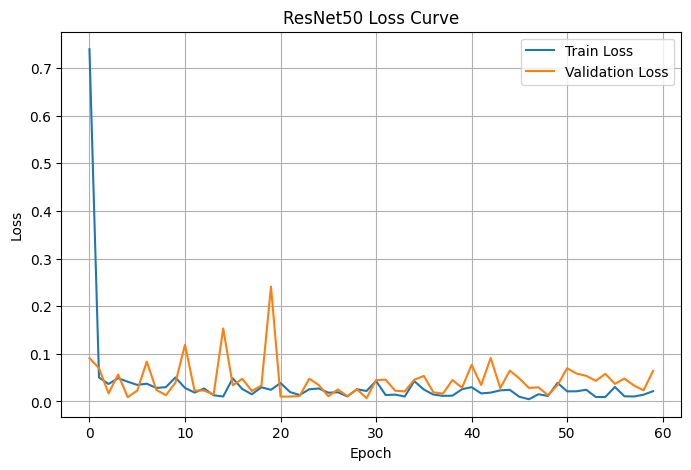

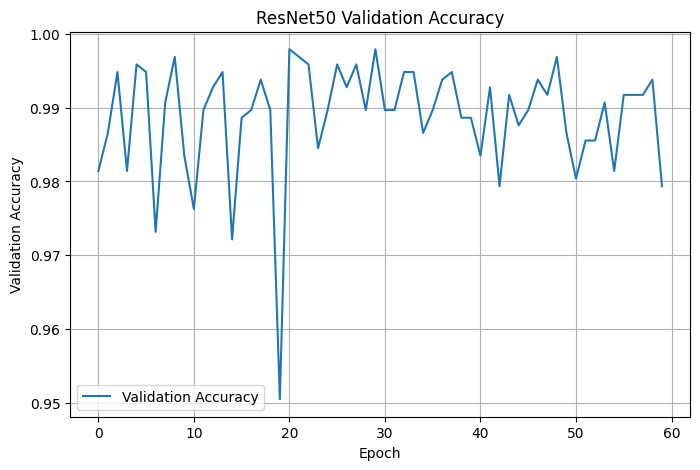

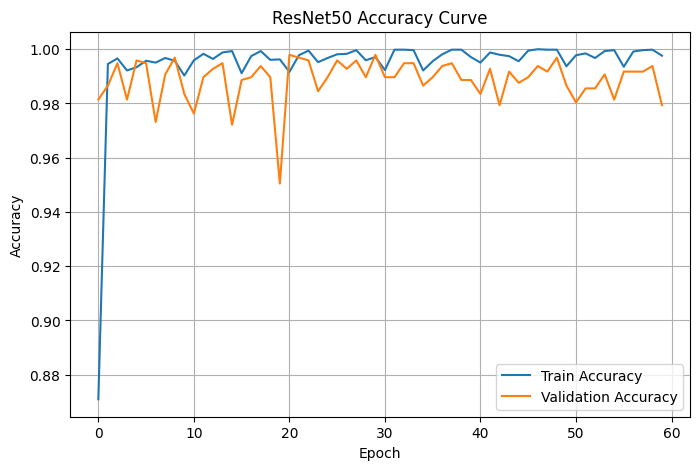

In [7]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss Curve")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ResNet50 Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(results_dir, "validation_accuracy_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Accuracy Curve")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300, bbox_inches="tight")
plt.show()


## Test Best Model and Metrics

In [8]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

test_loss = 0.0
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        test_loss += loss.item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

avg_test_loss = test_loss / len(test_loader)

metrics_df = pd.DataFrame({
    "Metric": [
        "Test Loss", "Accuracy", "Precision (Macro)", "Recall (Macro)",
        "F1-score (Macro)", "Precision (Weighted)", "Recall (Weighted)", "F1-score (Weighted)"
    ],
    "Value": [
        avg_test_loss,
        accuracy_score(all_labels, all_preds),
        precision_score(all_labels, all_preds, average="macro", zero_division=0),
        recall_score(all_labels, all_preds, average="macro", zero_division=0),
        f1_score(all_labels, all_preds, average="macro", zero_division=0),
        precision_score(all_labels, all_preds, average="weighted", zero_division=0),
        recall_score(all_labels, all_preds, average="weighted", zero_division=0),
        f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    ]
})

metrics_df.to_csv(os.path.join(results_dir, "resnet50_test_metrics.csv"), index=False)
print(metrics_df)


C:\Users\User\AppData\Local\Temp\ipykernel_3916\519992240.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_location=

                 Metric     Value
0             Test Loss  0.024950
1              Accuracy  0.992439
2     Precision (Macro)  0.992560
3        Recall (Macro)  0.991477
4      F1-score (Macro)  0.991151
5  Precision (Weighted)  0.993811
6     Recall (Weighted)  0.992439
7   F1-score (Weighted)  0.992370


## Classification Report and Confusion Matrix

In [9]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=test_dataset.classes,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv(os.path.join(results_dir, "classification_report.csv"))
print(report_df)

cm = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(cm, index=test_dataset.classes, columns=test_dataset.classes)
cm_df.to_csv(os.path.join(results_dir, "confusion_matrix.csv"))

print("Saved classification report and confusion matrix.")


                                precision    recall  f1-score     support
10Coleus scutellarioides(CS)     1.000000  1.000000  1.000000   13.000000
11Phyllanthus niruri(PN)         1.000000  1.000000  1.000000   14.000000
12Corchorus olitorius(CO)        1.000000  1.000000  1.000000   15.000000
13Momordica charantia (MC)       1.000000  1.000000  1.000000   11.000000
14Euphorbia hirta(EH)            1.000000  1.000000  1.000000   13.000000
15Curcuma longa(CL)              1.000000  0.909091  0.952381   11.000000
16Carmona retusa(CR)             1.000000  1.000000  1.000000   14.000000
17Senna alata(SA)                1.000000  1.000000  1.000000   12.000000
18Mentha cordifolia Opiz(MCO)    1.000000  1.000000  1.000000   11.000000
19Capsicum frutescens(CF)        1.000000  1.000000  1.000000   13.000000
1Hibiscus rosa-sinensis(HRS)     1.000000  1.000000  1.000000   12.000000
20Jatropha curcas(JC)            1.000000  1.000000  1.000000   15.000000
21Ocimum basilicum(OB)           1.000

## ROC-AUC Curve

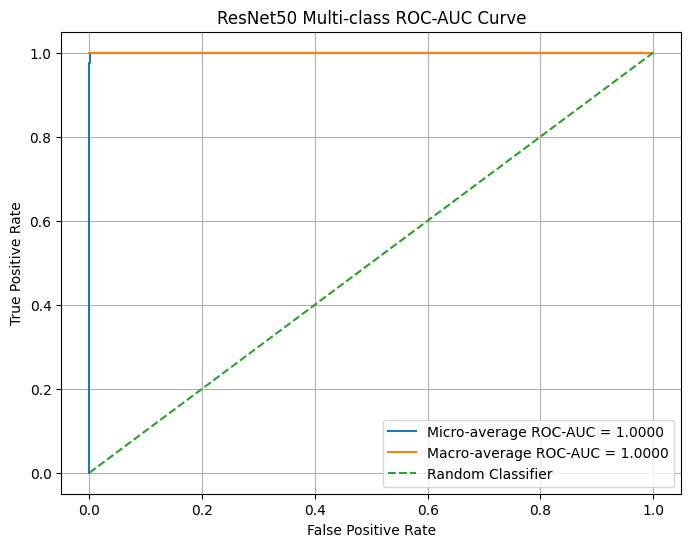

          Metric     Value
0  ROC-AUC Micro  0.999992
1  ROC-AUC Macro  1.000000


In [10]:
n_classes = len(test_dataset.classes)
y_true_bin = label_binarize(all_labels, classes=list(range(n_classes)))

fpr, tpr, roc_auc = {}, {}, {}

for class_idx in range(n_classes):
    fpr[class_idx], tpr[class_idx], _ = roc_curve(y_true_bin[:, class_idx], all_probs[:, class_idx])
    roc_auc[class_idx] = auc(fpr[class_idx], tpr[class_idx])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[class_idx] for class_idx in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for class_idx in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[class_idx], tpr[class_idx])

mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

roc_auc_df = pd.DataFrame({
    "Metric": ["ROC-AUC Micro", "ROC-AUC Macro"],
    "Value": [roc_auc["micro"], roc_auc["macro"]]
})
roc_auc_df.to_csv(os.path.join(results_dir, "roc_auc_scores.csv"), index=False)

plt.figure(figsize=(8,6))
plt.plot(fpr["micro"], tpr["micro"], label=f"Micro-average ROC-AUC = {roc_auc['micro']:.4f}")
plt.plot(fpr["macro"], tpr["macro"], label=f"Macro-average ROC-AUC = {roc_auc['macro']:.4f}")
plt.plot([0,1], [0,1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet50 Multi-class ROC-AUC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(os.path.join(results_dir, "roc_auc_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

print(roc_auc_df)


## Zip Results

In [11]:
shutil.make_archive(results_dir, "zip", results_dir)
print("Zipped results:", results_dir + ".zip")


Zipped results: resnet50_existing_combined_results.zip
